In [2]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
plt.style.use('ggplot')
from matplotlib.pyplot import figure
%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (12,8)

In [3]:
df = pd.read_csv(r'C:\Users\Aishw\dataset_filled.csv')

In [4]:
df.head()

,Title,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,released_date,released_year,star_freq,writer_freq,budget_was_predicted
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0,1980-06-13,1980.0,19,NaN,False
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0,1980-07-02,1980.0,5,NaN,False
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0,1980-06-20,1980.0,2,NaN,False
3,Airplane,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0,1980-07-02,1980.0,4,NaN,False
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0,1980-07-25,1980.0,18,NaN,False


In [9]:
df.drop(columns=['star_freq', 'writer_freq','released'], inplace=True)

In [ ]:
df.describe()

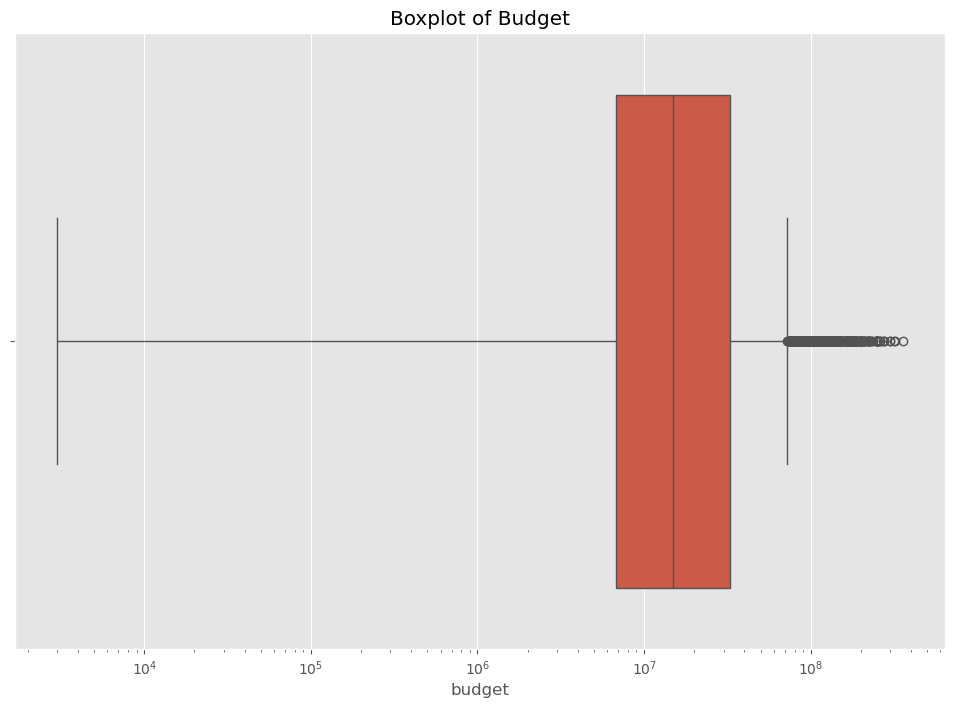

In [11]:
#Checking for any outliers in gross column
sns.boxplot(x=df['budget'])
plt.title('Boxplot of Budget')
plt.xscale('log')  # If needed
plt.show()

In [12]:
#Removing extreme outliers in budget column
Q1 = df['budget'].quantile(0.25)
Q3 = df['budget'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_filtered = df[((df['budget'] >= lower_bound) & (df['budget'] >= upper_bound))]

In [13]:
#creating a flag column to highlight outliers
df['budget_outlier'] = ~df.index.isin(df_filtered.index)

C:\Users\Aishw\AppData\Local\Temp\ipykernel_20860\1236278287.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='budget_outlier', y='gross', data=df, estimator='mean', palette='Set2')


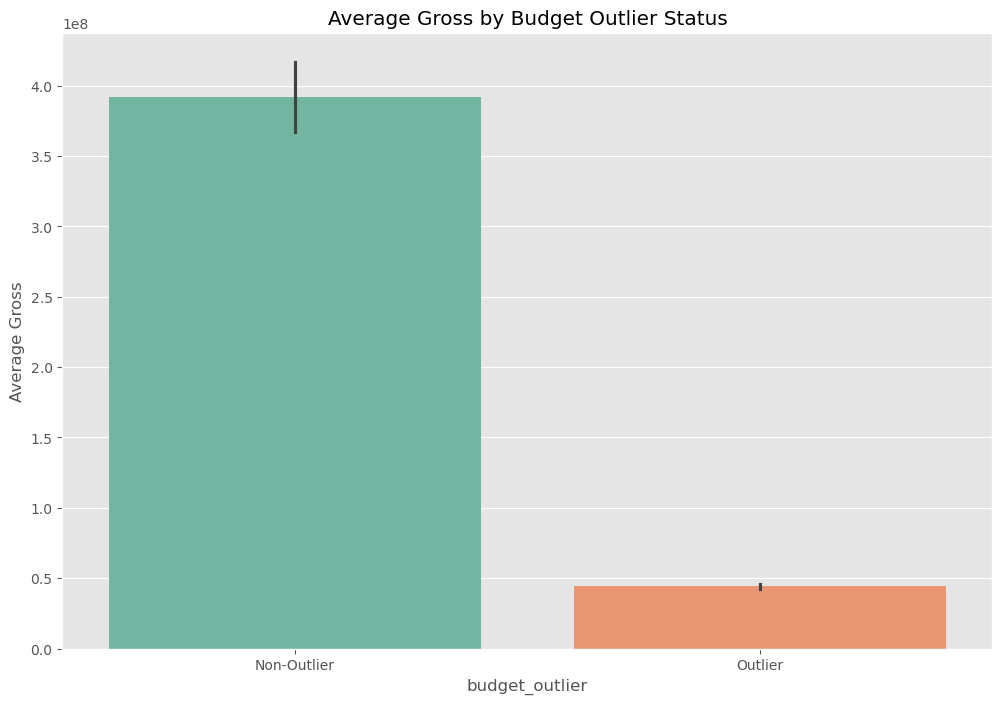

In [14]:
sns.barplot(x='budget_outlier', y='gross', data=df, estimator='mean', palette='Set2')
plt.xticks([0, 1], ['Non-Outlier', 'Outlier'])
plt.ylabel("Average Gross")
plt.title("Average Gross by Budget Outlier Status")
plt.show()

In [17]:
#Checking what are the movies with high budgets(outliers)
# Filter only gross outliers
budget_outliers_df = df[df['budget_outlier'] == True]

# Sort by gross descending
high_budget_movies = budget_outliers_df.sort_values(by='budget', ascending=False)

# View top 10
high_budget_movies[['Title', 'gross', 'budget', 'rating']].head(10)

,Title,gross,budget,rating
4692,Jarhead,97076152.0,72000000.0,R
4056,Signs,408247917.0,72000000.0,PG-13
2646,Braveheart,213216216.0,72000000.0,R
3963,The Majestic,37317673.0,72000000.0,PG
3897,The Last Castle,27642707.0,72000000.0,R
3340,Doctor Dolittle,294456605.0,71500000.0,PG-13
5305,Body of Lies,115900897.0,70000000.0,R
4682,Munich,130982129.0,70000000.0,R
2268,Cliffhanger,255000211.0,70000000.0,R
5319,Fool's Gold,111231041.0,70000000.0,PG-13


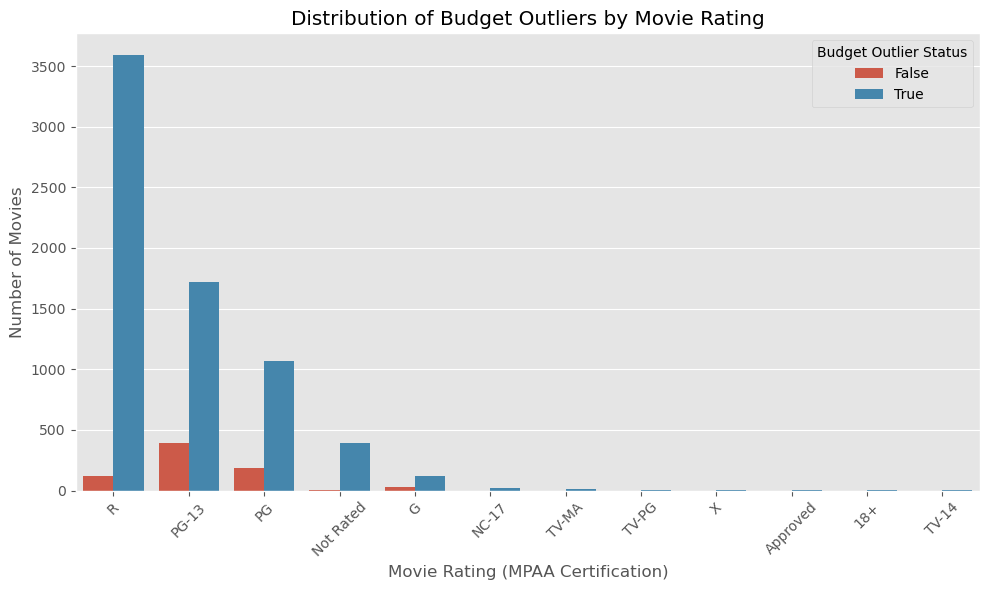

In [75]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='rating', hue='budget_outlier', order=df['rating'].value_counts().index)

plt.title('Distribution of Budget Outliers by Movie Rating')
plt.xlabel('Movie Rating (MPAA Certification)')
plt.ylabel('Number of Movies')
plt.legend(title='Budget Outlier Status')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
df['ROI'] = df['gross'] / df['budget']

In [83]:
outliers_df = df[df['budget_outlier'] == True]


In [84]:
# Create a new column: Is R-rated?
outliers_df['is_R_rated'] = outliers_df['rating'] == 'R'

# Group by R-rated or not
avg_metrics = outliers_df.groupby('is_R_rated')[['gross', 'ROI']].mean().reset_index()
avg_metrics.columns = ['Is R-rated', 'Average Gross', 'Average ROI']

print(avg_metrics)


   Is R-rated  Average Gross  Average ROI
0       False   5.290158e+07     2.723817
1        True   3.597336e+07     7.802926


C:\Users\Aishw\AppData\Local\Temp\ipykernel_20860\1640756637.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_df['is_R_rated'] = outliers_df['rating'] == 'R'


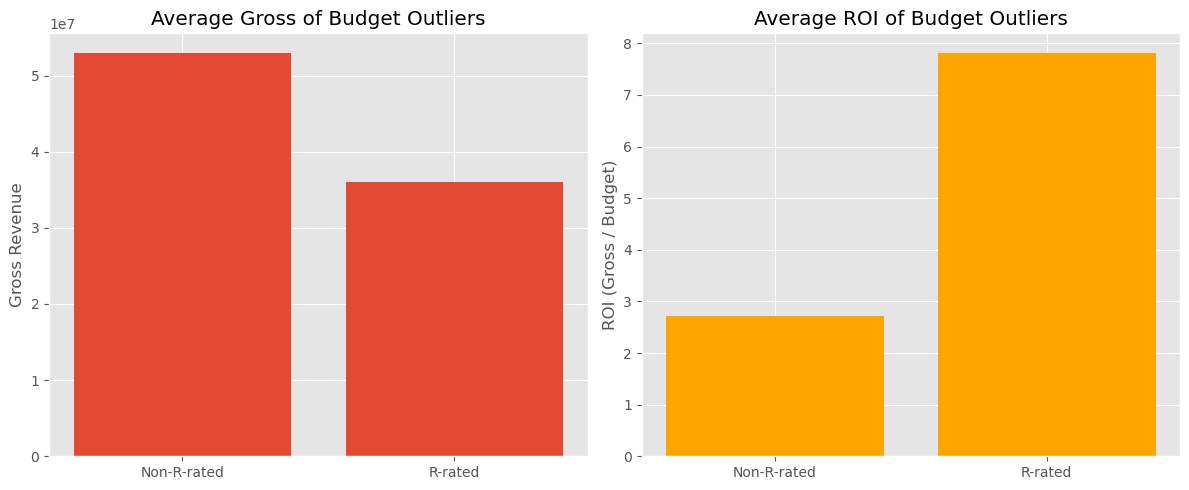

In [85]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

# Average Gross
ax[0].bar(['Non-R-rated', 'R-rated'], avg_metrics['Average Gross'])
ax[0].set_title('Average Gross of Budget Outliers')
ax[0].set_ylabel('Gross Revenue')

# Average ROI
ax[1].bar(['Non-R-rated', 'R-rated'], avg_metrics['Average ROI'], color='orange')
ax[1].set_title('Average ROI of Budget Outliers')
ax[1].set_ylabel('ROI (Gross / Budget)')

plt.tight_layout()
plt.show()

In [86]:
genre_rating_group = df.groupby(['genre', 'rating']).agg(
    avg_gross=('gross', 'mean'),
    avg_roi=('ROI', 'mean'),
    count=('Title', 'count')  # Optional: see sample size
).reset_index()

# Step 3: Sort (optional - for top performers)
genre_rating_group = genre_rating_group.sort_values(by='avg_roi', ascending=False)

# Step 4: View result
print(genre_rating_group.head(10))

        genre     rating     avg_gross    avg_roi  count
64     Horror          R  4.495209e+07  76.632755    258
6      Action      TV-MA  6.999925e+08  14.583177      1
54     Family         PG  3.058996e+08  12.695428      7
63     Horror      PG-13  7.464866e+07  11.272787     44
60     Horror      NC-17  2.956630e+06   8.447514      1
21  Animation      TV-PG  2.994216e+08   7.190104      2
16  Animation  Not Rated  6.850670e+07   6.018578     12
7   Adventure   Approved  3.656528e+07   5.625428      1
29     Comedy          G  1.001722e+08   4.419076     16
81   Thriller      PG-13  6.239359e+07   4.130851      3


In [18]:
#Removing extreme outliers in gross column
df['gross_outlier'] = df['gross'] > 100_000_000

In [87]:
df['ROI'] = df['gross'] / df['budget']
df.groupby('gross_outlier')['ROI'].mean()

gross_outlier
False     2.157704
True     16.934048
Name: ROI, dtype: float64

In [13]:
max_ROI = df.loc[df['ROI'].idxmax()]
max_budget = df.loc[df['budget'].idxmax()]
print("Max budget movie :", max_budget['Title']," | budget:", max_budget['budget'])

Max budget movie : Avengers: Endgame  | budget: 356000000.0


In [9]:
print("🎯 Max ROI Movie:", max_ROI['Title'], "| ROI:", max_ROI['ROI'])

🎯 Max ROI Movie: Paranormal Activity | ROI: 12890.386666666667


In [91]:
# Step 2: Group by genre and gross outlier
roi_by_genre_outlier = df.groupby(['genre', 'gross_outlier']).agg(
    avg_roi=('ROI', 'mean'),
    median_roi=('ROI', 'median'),
    count=('Title', 'count')
).reset_index()

# Step 3: Sort (optional)
roi_by_genre_outlier = roi_by_genre_outlier.sort_values(by='avg_roi', ascending=False)

# View top rows
print(roi_by_genre_outlier.head(10))


        genre  gross_outlier     avg_roi  median_roi  count
20     Horror           True  435.274881   12.759229     41
15     Family           True   41.709003   41.709003      2
13      Drama           True    7.464547    4.624684    151
9      Comedy           True    6.989266    4.422983    290
19     Horror          False    6.509373    2.157719    281
7   Biography           True    6.462111    5.097939     58
24    Mystery           True    6.169666    5.822050      5
28     Sci-Fi           True    5.994424    5.994424      1
11      Crime           True    5.862248    3.848575     65
5   Animation           True    4.872190    4.026002    189


C:\Users\Aishw\AppData\Local\Temp\ipykernel_20860\2548062224.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='gross_outlier', y='budget', data=df, estimator='median', palette='Set3')


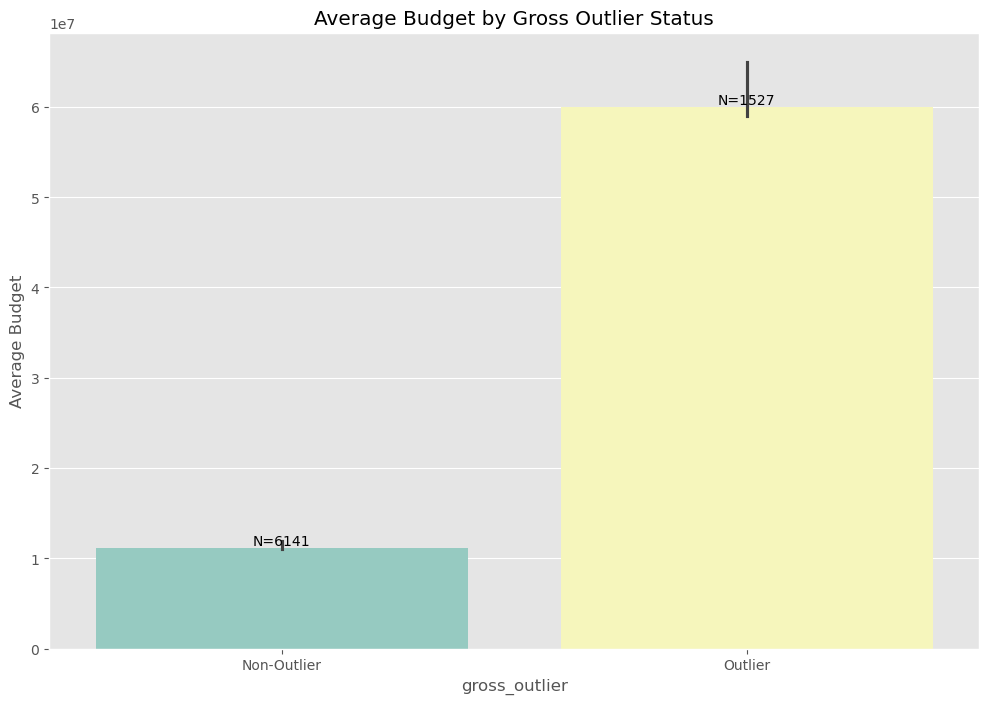

In [19]:
ax = sns.barplot(x='gross_outlier', y='budget', data=df, estimator='median', palette='Set3')
plt.xticks([0, 1], ['Non-Outlier', 'Outlier'])
plt.ylabel("Average Budget")
plt.title("Average Budget by Gross Outlier Status")
counts = df['gross_outlier'].value_counts()
for i, count in enumerate(counts):
    ax.text(i, ax.patches[i].get_height(), f'N={count}', ha='center', va='bottom', fontsize=10, color='black')
plt.show()
plt.show()

In [20]:
print("Outlier count:", df[df['gross_outlier']].shape[0])
print("Non-outlier count:", df[~df['gross_outlier']].shape[0])

Outlier count: 1527
Non-outlier count: 6141


In [22]:

#Finding the top most box-office hit movie
# Filter only gross outliers
gross_outliers_df = df[df['gross_outlier'] == True]

# Sort by gross descending
top_grossing_movies = gross_outliers_df.sort_values(by='gross', ascending=False)

# View top 10
top_grossing_movies[['Title', 'gross', 'budget', 'rating']].head(10)

,Title,gross,budget,rating
5445,Avatar,2.847246e+09,237000000.0,PG-13
7445,Avengers: Endgame,2.797501e+09,356000000.0,PG-13
3045,Titanic,2.201647e+09,200000000.0,PG-13
6663,Star Wars: Episode VII - The Force Awakens,2.069522e+09,245000000.0,PG-13
7244,Avengers: Infinity War,2.048360e+09,321000000.0,PG-13
7480,The Lion King,1.670728e+09,260000000.0,PG
6653,Jurassic World,1.670516e+09,150000000.0,PG-13
6043,The Avengers,1.518816e+09,220000000.0,PG-13
6646,Furious 7,1.515341e+09,190000000.0,PG-13
7494,Frozen II,1.450027e+09,150000000.0,PG


C:\Users\Aishw\AppData\Local\Temp\ipykernel_20860\828865339.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=gross_outliers_df, x='genre', order=gross_outliers_df['genre'].value_counts().index, palette='Set2')


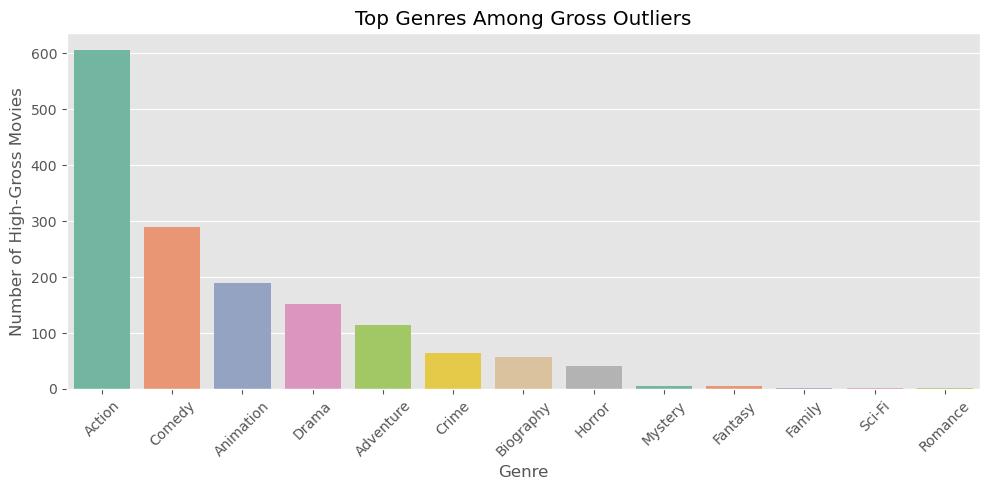

In [23]:
#Top genres among the top grossing movies
plt.figure(figsize=(10, 5))
sns.countplot(data=gross_outliers_df, x='genre', order=gross_outliers_df['genre'].value_counts().index, palette='Set2')
plt.title("Top Genres Among Gross Outliers")
plt.xlabel("Genre")
plt.ylabel("Number of High-Gross Movies")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
Action_df = df[df['genre'].str.contains("Action", case=False, na=False)]

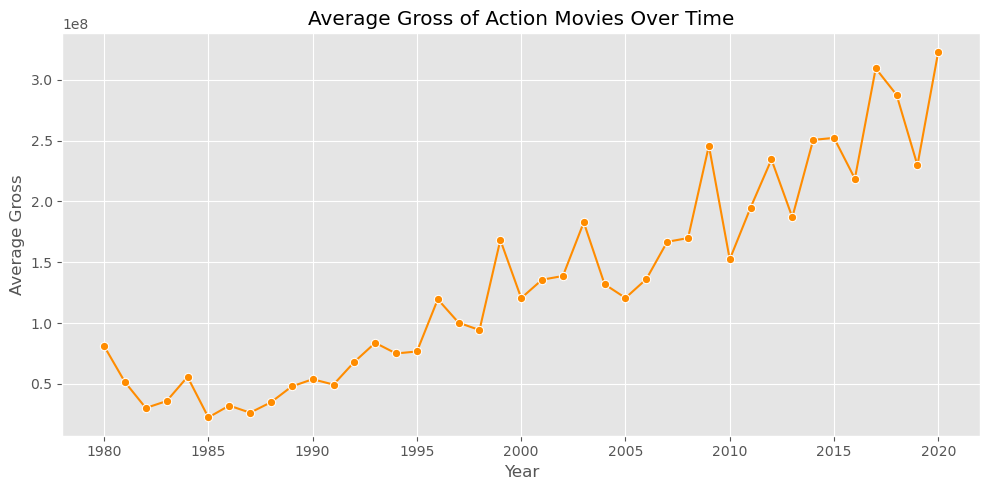

In [25]:
# Group by year and compute average gross of Sci-Fi movies
action_yearly = Action_df.groupby('released_year')['gross'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=action_yearly, x='released_year', y='gross', marker='o', color='darkorange')
plt.title("Average Gross of Action Movies Over Time")
plt.xlabel("Year")
plt.ylabel("Average Gross")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df.drop(columns=['year'], inplace=True)

In [95]:
cols_to_clean = ['director', 'writer', 'star', 'company']

for col in cols_to_clean:
    df[col] = df[col].astype(str)                    # Ensure text format
    df[col] = df[col].str.strip()                    # Remove leading/trailing spaces
    df[col] = df[col].str.replace(r'\s+', ' ', regex=True)  # Replace multiple spaces with single space
    df[col] = df[col].str.title()                    # Standardize to Title Case


In [96]:
#Calculating profit earned
df['profit'] = df['gross'] - df['budget']


In [97]:
company_metrics = df.groupby('company').agg(
    total_profit=('profit', 'sum'),
    movie_count=('Title', 'count'),
    total_budget=('budget', 'sum')
).reset_index()

In [99]:
# Compute ROI = profit / budget
company_metrics['roi'] = company_metrics['total_profit'] / company_metrics['total_budget']

# Get top 10 companies by total profit
top10 = company_metrics.sort_values(by='total_profit', ascending=False).head(10)
print(top10)

                    company  total_profit  movie_count  total_budget       roi
2322           Warner Bros.  3.660572e+10          334  2.019187e+10  1.812893
2282     Universal Pictures  3.585651e+10          377  1.666701e+10  2.151347
2258  Twentieth Century Fox  2.836710e+10          240  1.188995e+10  2.385804
729       Columbia Pictures  2.713992e+10          332  1.586902e+10  1.710246
1816     Paramount Pictures  2.636801e+10          320  1.412605e+10  1.866623
2319   Walt Disney Pictures  2.566848e+10          123  1.065941e+10  2.408058
1715        New Line Cinema  1.403306e+10          174  5.850736e+09  2.398512
1599         Marvel Studios  1.240159e+10           12  2.664000e+09  4.655252
889    Dreamworks Animation  8.529613e+09           28  3.344000e+09  2.550722
890     Dreamworks Pictures  7.655183e+09           76  3.980258e+09  1.923288


In [14]:
# Create a new column for profit if not already done
df['profit'] = df['gross'] - df['budget']

# Group by genre and sum the profit
genre_profit = df.groupby('genre')['profit'].sum().sort_values(ascending=False)

# Display the top genre
top_genre = genre_profit.idxmax()
top_profit = genre_profit.max()

print(f"🎬 Top Genre by Total Profit: {top_genre} | Profit: ${top_profit/1e9:.2f} Billion")


🎬 Top Genre by Total Profit: Action | Profit: $156.99 Billion


C:\Users\Aishw\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127916 (\N{CLAPPER BOARD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


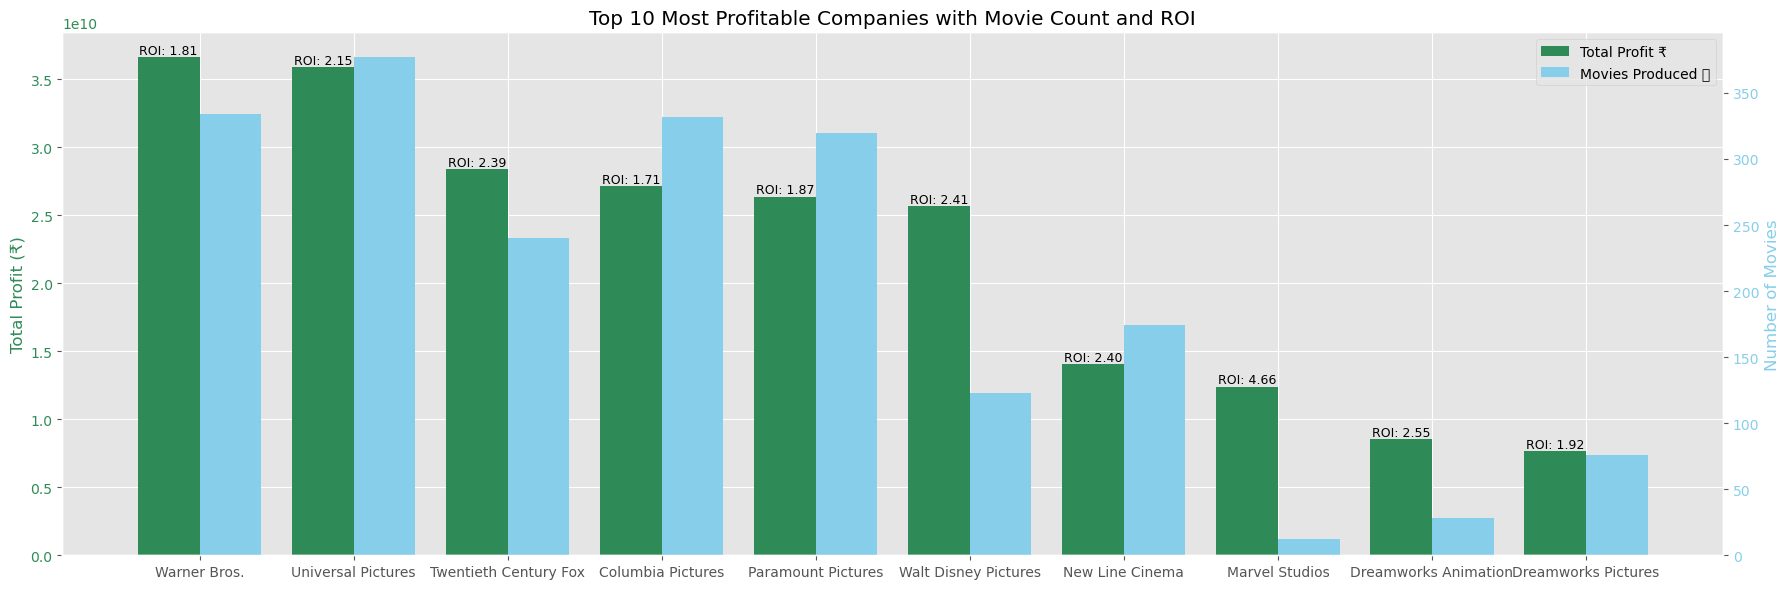

In [32]:
# Set positions
x = np.arange(len(top10))
bar_width = 0.4

fig, ax1 = plt.subplots(figsize=(18, 6))

# Left axis: Total Profit
bars1 = ax1.bar(x - bar_width/2, top10['total_profit'], width=bar_width, label='Total Profit ₹', color='seagreen')
ax1.set_ylabel("Total Profit (₹)", color='seagreen')
ax1.tick_params(axis='y', labelcolor='seagreen')

# ROI annotations on top of profit bars
for i, roi in enumerate(top10['roi']):
    ax1.text(x[i] - bar_width/2, top10['total_profit'].iloc[i] + 1e7, f'ROI: {roi:.2f}', ha='center', va='bottom', fontsize=9)

# Right axis: Movie Count
ax2 = ax1.twinx()
bars2 = ax2.bar(x + bar_width/2, top10['movie_count'], width=bar_width, label='Movies Produced 🎬', color='skyblue')
ax2.set_ylabel("Number of Movies", color='skyblue')
ax2.tick_params(axis='y', labelcolor='skyblue')

# X-axis setup
plt.xticks(x, top10['company'], rotation=45, ha='right')
plt.title("Top 10 Most Profitable Companies with Movie Count and ROI")
fig.tight_layout()
plt.grid(axis='y')

# Combine legends from both axes
bars = bars1 + bars2
labels = ['Total Profit ₹', 'Movies Produced 🎬']
bars = [bars1[0], bars2[0]]  # Just one bar from each for legend
ax1.legend(bars, labels, loc='upper right')

plt.show()

In [100]:
studio_genre_roi = df.groupby(['company', 'genre']).agg(
    total_movies=('Title', 'count'),
    avg_budget=('budget', 'mean'),
    avg_gross=('gross', 'mean'),
    avg_roi=('ROI', 'mean'),
    median_roi=('ROI', 'median')
).reset_index()

# Filter for meaningful data (e.g., at least 5 films)
studio_genre_roi = studio_genre_roi[studio_genre_roi['total_movies'] >= 5]

# Sort by avg ROI
studio_genre_roi = studio_genre_roi.sort_values('avg_roi', ascending=False)

print(studio_genre_roi.head(10))

                            company   genre  total_movies    avg_budget  \
2496                New Line Cinema  Horror            17  1.896471e+07   
2649             Paramount Pictures  Horror            11  5.977273e+06   
1699              Gold Circle Films  Comedy             5  1.140000e+07   
3133           Summit Entertainment  Comedy             9  2.235211e+07   
2312           Marimark Productions  Comedy             5  7.730184e+06   
2975                    Screen Gems   Drama            12  1.924000e+07   
2242                      Lucasfilm  Action             8  1.391875e+08   
3369             Universal Pictures  Horror            17  1.439664e+07   
1611       Fox Searchlight Pictures  Comedy            24  8.456920e+06   
2739  Polygram Filmed Entertainment  Comedy            11  1.492335e+07   

         avg_gross    avg_roi  median_roi  
2496  1.721065e+08  35.625181    8.044705  
2649  5.592903e+07  19.271332    6.846429  
1699  1.039743e+08  16.584059    3.139747 

In [33]:
#Finding the sucessful star-writer duo
df['star_writer'] = df['star'] + '&' + df['writer']

In [34]:
df['is_hit'] = (df['gross'] > 100_000_000) & (df['score'] > 7.5)

In [35]:
duo_hits = df.groupby('star_writer')['is_hit'].sum().reset_index()
duo_hits.rename(columns={'is_hit': 'hit_movie_count'}, inplace=True)

In [38]:
duo_stats= df.groupby('star_writer').agg({
    'gross':'mean',
    'score':'mean',
    'Title':'count'
}).rename(columns = {'Title' : 'movie_count'}).reset_index()


In [39]:
duo_stats_filtered = duo_stats[duo_stats['movie_count'] > 1]

In [40]:
duo_summary = pd.merge(duo_stats_filtered, duo_hits, on = 'star_writer')

In [41]:
top_10_duo = duo_summary.sort_values(by = 'hit_movie_count', ascending = False).head(10)

C:\Users\Aishw\AppData\Local\Temp\ipykernel_20860\1255210178.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = top_10_duo, x = 'hit_movie_count', y = 'star_writer', palette = 'Blues_d')


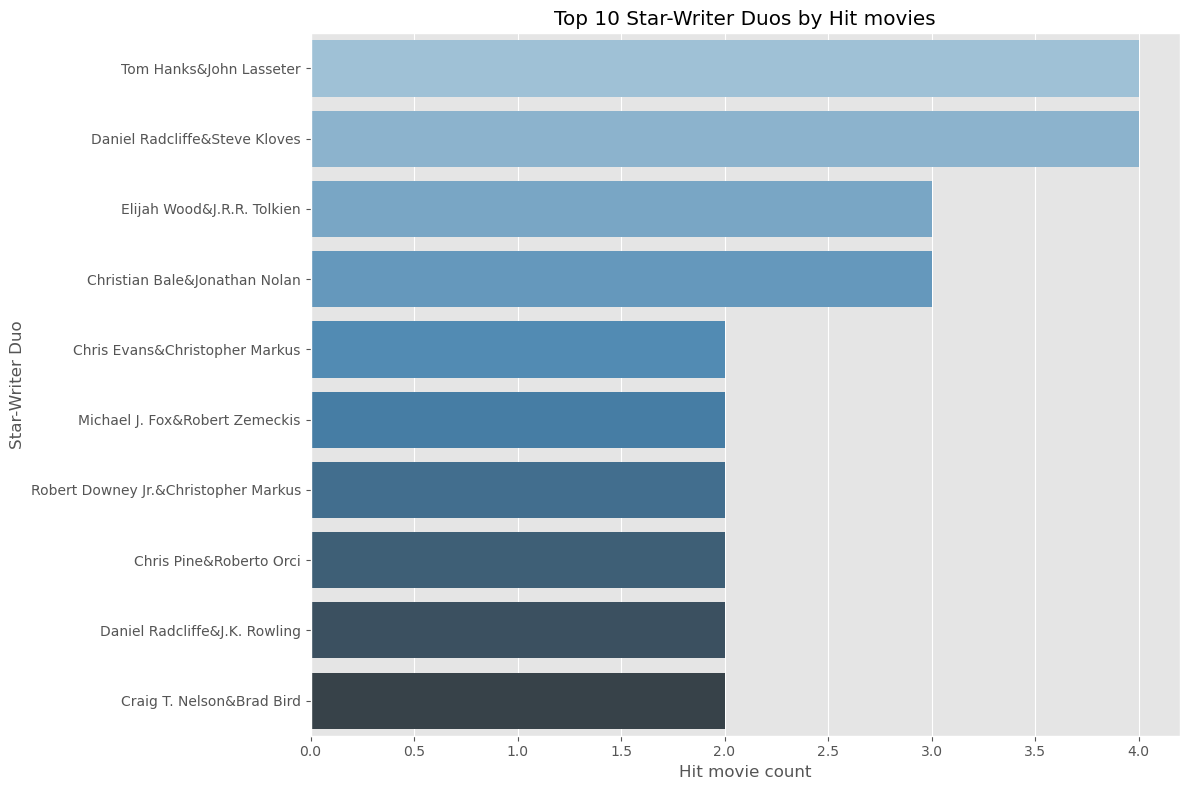

In [42]:
sns.barplot(data = top_10_duo, x = 'hit_movie_count', y = 'star_writer', palette = 'Blues_d')
plt.title('Top 10 Star-Writer Duos by Hit movies')
plt.xlabel('Hit movie count')
plt.ylabel('Star-Writer Duo')
plt.tight_layout()
plt.show()

In [43]:
cols_to_convert = ['budget', 'gross', 'score', 'runtime', 'votes', 'profit']
for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [44]:
df_cleaned = df.select_dtypes(include =['number']).dropna()

In [45]:
corr_matrix = df_cleaned.corr()

In [46]:
print(corr_matrix)

                   year     score     votes    budget     gross   runtime  \
year           1.000000  0.099010  0.217881  0.307850  0.258274  0.119779   
score          0.099010  1.000000  0.413449  0.053926  0.187249  0.399394   
votes          0.217881  0.413449  1.000000  0.478639  0.630989  0.310689   
budget         0.307850  0.053926  0.478639  1.000000  0.757235  0.292599   
gross          0.258274  0.187249  0.630989  0.757235  1.000000  0.246020   
runtime        0.119779  0.399394  0.310689  0.292599  0.246020  1.000000   
released_year  0.997636  0.106580  0.213617  0.298817  0.251435  0.119319   
profit         0.223936  0.208027  0.620888  0.630272  0.984347  0.213484   

               released_year    profit  
year                0.997636  0.223936  
score               0.106580  0.208027  
votes               0.213617  0.620888  
budget              0.298817  0.630272  
gross               0.251435  0.984347  
runtime             0.119319  0.213484  
released_year      

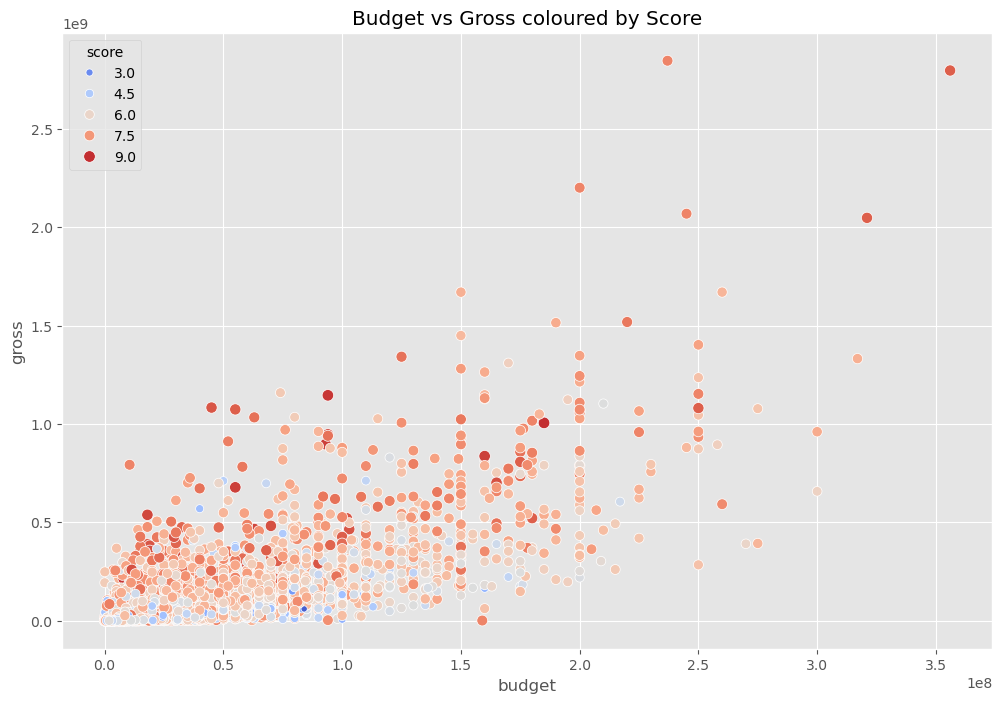

In [47]:
#Looking for low-budget movies with high score
sns.scatterplot(data = df, x = 'budget', y = 'gross', hue = 'score', palette = 'coolwarm', size = 'score')
plt.title('Budget vs Gross coloured by Score')
plt.show()

In [48]:
df['efficiency'] =  df['gross'] / df['budget']


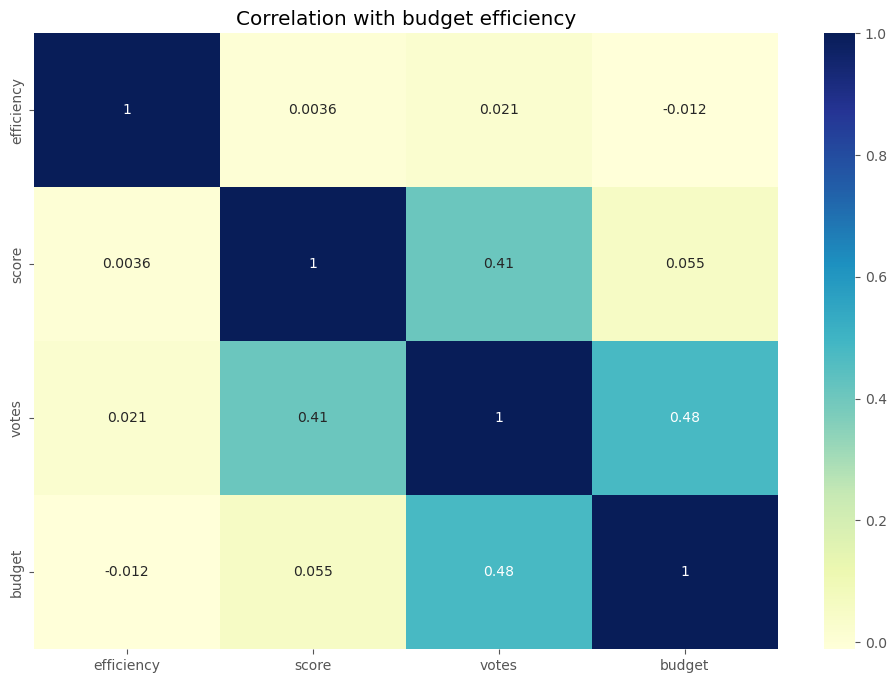

In [49]:
eff_corr = df[['efficiency', 'score', 'votes', 'budget']].corr()
sns.heatmap(eff_corr, annot = True, cmap= 'YlGnBu')
plt.title('Correlation with budget efficiency')
plt.show()

In [51]:
# Define thresholds to uncover low-budget, high score hit movies
low_budget_thresh = df['budget'].quantile(0.25)
high_score_thresh = df['score'].quantile(0.75)
high_gross_thresh = df['gross'].quantile(0.75)

hidden_gems = df[
    (df['budget'] <= low_budget_thresh) & 
    (df['score'] >= high_score_thresh) &
    (df['gross'] >= high_gross_thresh)
]
print(hidden_gems[['Title', 'budget', 'score', 'gross']])

                            Title        budget  score        gross
3                        Airplane  3.500000e+06    7.7   83453539.0
475                The Terminator  6.400000e+06    8.0   78371200.0
852                       Platoon  6.000000e+06    8.1  138545632.0
2458  Four Weddings and a Funeral  4.400000e+06    7.1  245700832.0
3089               The Full Monty  3.500000e+06    7.2  257938649.0
3689                 Billy Elliot  5.000000e+06    7.7  109283018.0
4253          Lost in Translation  4.000000e+06    7.7  118686937.0
4456                          Saw  1.200000e+06    7.6  103911669.0
4477                        Crash  6.500000e+06    7.7   98410061.0
4863          The Lives of Others  2.000000e+06    8.4   77356942.0
7056                      Get Out  4.500000e+06    7.7  255589157.0
7330                    Searching  8.800000e+05    7.6   75462037.0
7497     The Peanut Butter Falcon  6.200000e+06    7.6  133031473.0
7630                         Open  2.007199e+06 

In [52]:
hidden_gems['genre'].value_counts()

genre
Drama        5
Comedy       4
Horror       2
Action       1
Crime        1
Adventure    1
Name: count, dtype: int64

In [53]:
genre_full = df['genre'].value_counts(normalize=True)

# Hidden gems genre distribution
genre_hidden = hidden_gems['genre'].value_counts(normalize=True)


In [54]:
genre_compare = pd.concat([genre_full, genre_hidden], axis=1)
genre_compare.columns = ['Overall %', 'Hidden Gem %']
genre_compare['Difference'] = genre_compare['Hidden Gem %'] - genre_compare['Overall %']
genre_compare = genre_compare.sort_values('Difference', ascending=False)

print(genre_compare)

           Overall %  Hidden Gem %  Difference
genre                                         
Drama       0.197966      0.357143    0.159177
Horror      0.041993      0.142857    0.100864
Adventure   0.055686      0.071429    0.015743
Crime       0.071857      0.071429   -0.000428
Comedy      0.292775      0.285714   -0.007061
Action      0.222353      0.071429   -0.150924
Biography   0.057773           NaN         NaN
Animation   0.044079           NaN         NaN
Fantasy     0.005738           NaN         NaN
Mystery     0.002608           NaN         NaN
Thriller    0.002087           NaN         NaN
Family      0.001435           NaN         NaN
Sci-Fi      0.001304           NaN         NaN
Romance     0.001304           NaN         NaN
Western     0.000391           NaN         NaN
Musical     0.000261           NaN         NaN
Music       0.000130           NaN         NaN
History     0.000130           NaN         NaN
Sport       0.000130           NaN         NaN


C:\Users\Aishw\AppData\Local\Temp\ipykernel_20860\3435725137.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = hidden_gems, y= 'genre', order = hidden_gems['genre'].value_counts().index, palette = 'Set2')


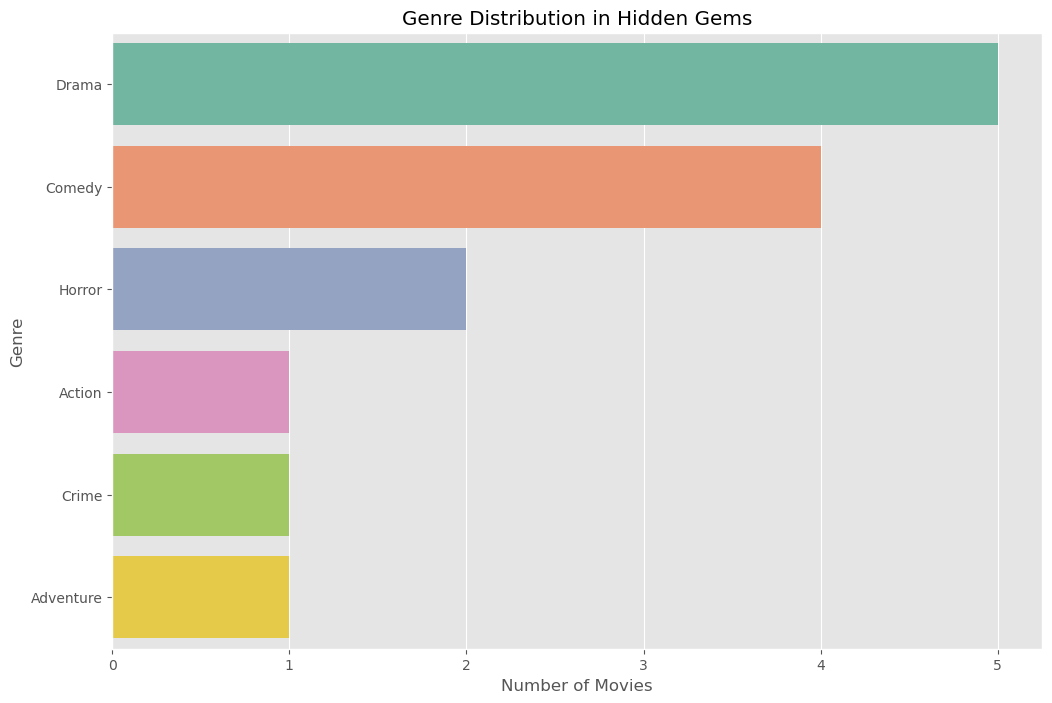

In [55]:
sns.countplot(data = hidden_gems, y= 'genre', order = hidden_gems['genre'].value_counts().index, palette = 'Set2')
plt.title("Genre Distribution in Hidden Gems")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")
plt.show()

In [56]:
#Step-by-Step Strategy to Explore Why a Movie Flops
df['flop'] = df['efficiency'] < 1.0

In [57]:
flops = df[df['flop'] == True]
hits = df[df['flop'] == False]

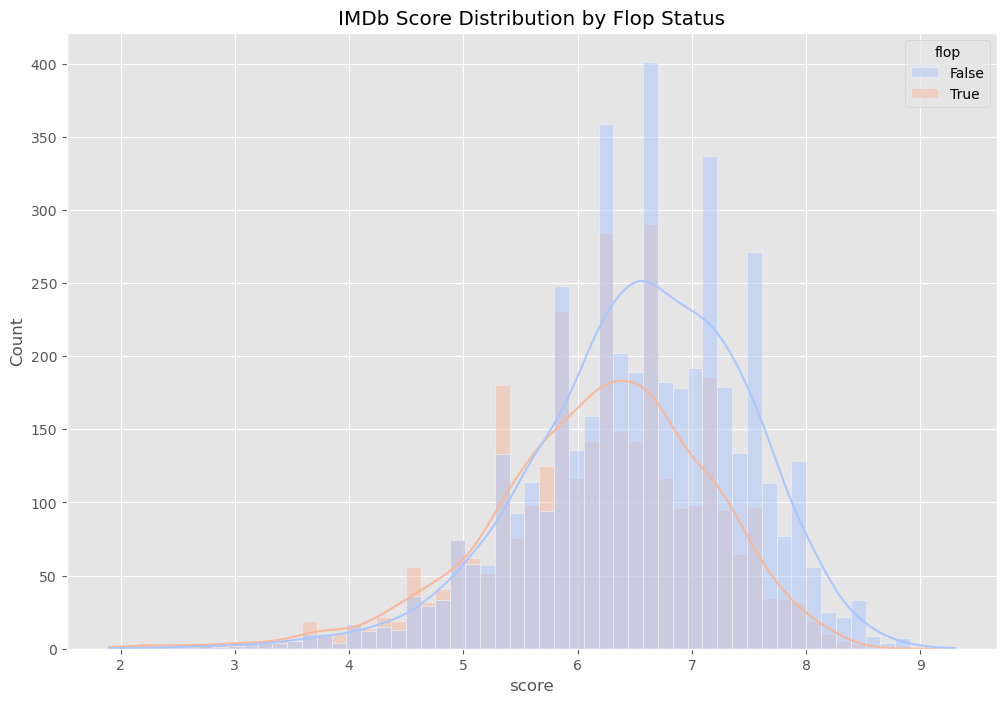

In [58]:
sns.histplot(data=df, x='score', hue='flop', kde=True, palette='coolwarm')
plt.title("IMDb Score Distribution by Flop Status")
plt.show()

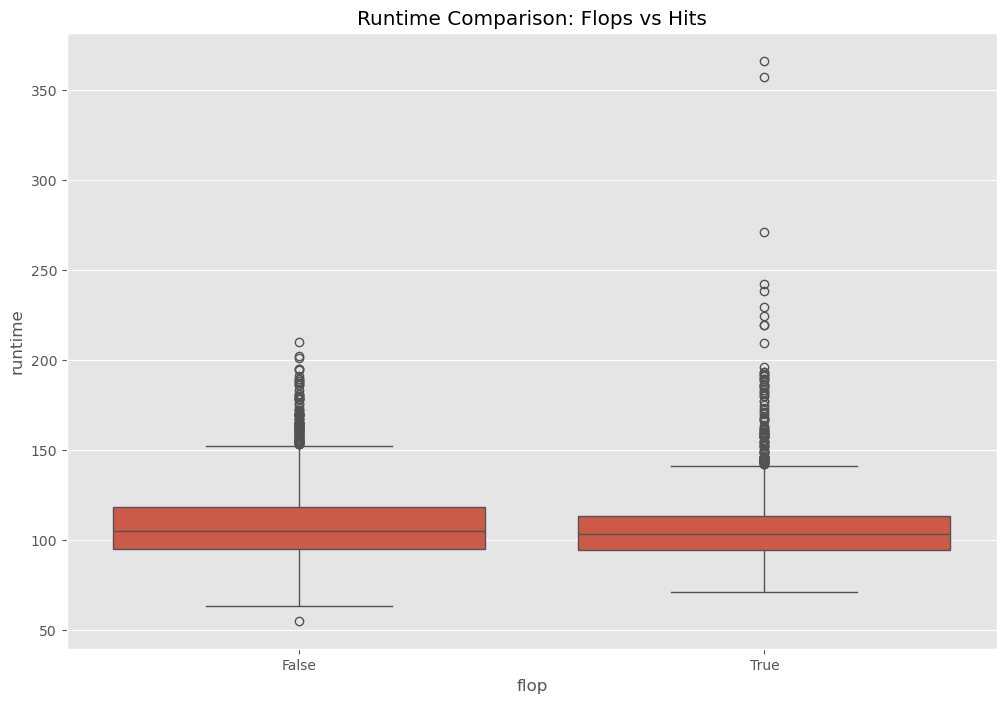

In [59]:
sns.boxplot(data=df, x='flop', y='runtime')
plt.title("Runtime Comparison: Flops vs Hits")
plt.show()

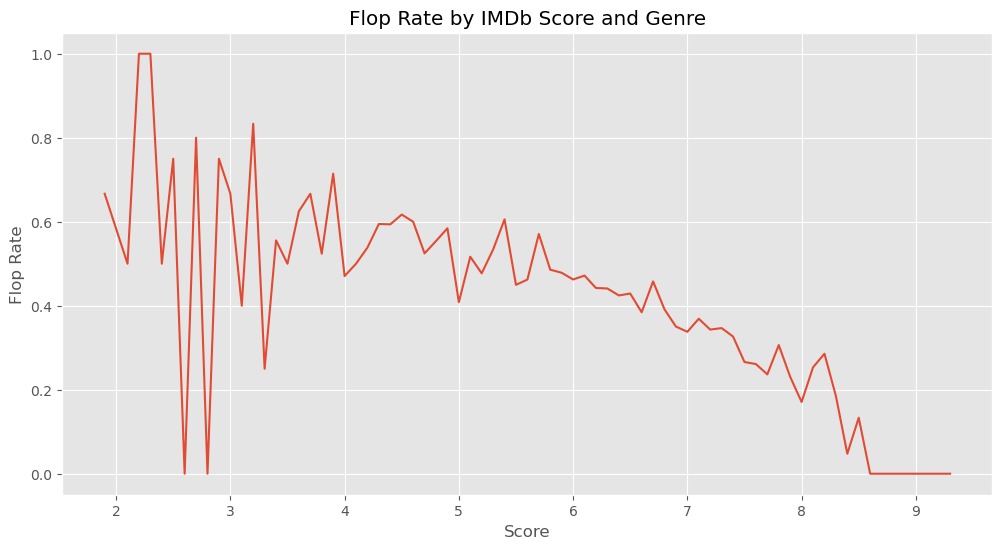

In [60]:
df.groupby(['score'])['flop'].mean().plot(kind='line', figsize=(12,6))
plt.title("Flop Rate by IMDb Score and Genre")
plt.xlabel("Score")
plt.ylabel("Flop Rate")
plt.grid(True)
plt.show()

In [61]:
genre_flop_rate = df.groupby('genre')['flop'].mean().sort_values(ascending=False)
print(genre_flop_rate)

genre
Sport        1.000000
Music        1.000000
Family       0.636364
Romance      0.600000
Drama        0.538208
Crime        0.517241
Sci-Fi       0.500000
Biography    0.478555
Adventure    0.416862
Comedy       0.409354
Mystery      0.350000
Action       0.334311
Western      0.333333
Thriller     0.312500
Fantasy      0.295455
Horror       0.288820
Animation    0.221893
History      0.000000
Musical      0.000000
Name: flop, dtype: float64


In [62]:
star_counts = df['star'].value_counts()
flop_rate = df.groupby('star')['flop'].mean()

In [63]:
# Combine into one DataFrame
star_stats = pd.DataFrame({
    'movie_count': star_counts,
    'flop_rate': flop_rate
}).dropna()

In [64]:
reliable_stars = star_stats[star_stats['movie_count'] >= 3]
print(reliable_stars.sort_values('flop_rate', ascending=False).head(10))

                 movie_count  flop_rate
star                                   
Helen Slater               3        1.0
James Duval                3        1.0
Anthony Edwards            4        1.0
Anne Parillaud             3        1.0
Anne Bancroft              3        1.0
Theresa Russell            3        1.0
Billy Crudup               4        1.0
Asia Argento               3        1.0
Jessica Lange              9        1.0
Jeremy Irons              10        1.0


In [65]:
# Identify Top 5 Countries by Number of Movies
top_countries = df['country'].value_counts().head(10).index
print("Top 10 movie-producing countries:", list(top_countries))

Top 10 movie-producing countries: ['United States', 'United Kingdom', 'France', 'Canada', 'Germany', 'Australia', 'Japan', 'India', 'Italy', 'Spain']


In [66]:
df_top_countries = df[df['country'].isin(top_countries)]

In [67]:
country_flop_counts = df_top_countries.groupby(['country', 'flop']).size().unstack(fill_value=0)
country_flop_counts.columns = ['Hit', 'Flop']

In [68]:
country_flop_counts['Total'] = country_flop_counts['Hit'] + country_flop_counts['Flop']

In [69]:
country_flop_counts['Success Rate (%)'] = round(country_flop_counts['Hit'] / country_flop_counts['Total'] * 100, 2)
country_flop_counts = country_flop_counts.sort_values('Total', ascending=False)

In [70]:
df_top_countries['profit_margin'] = (df_top_countries['gross'] - df_top_countries['budget']) / df_top_countries['budget']
df_top_countries['efficiency'] = df_top_countries['gross'] / df_top_countries['budget']
profit_stats = df_top_countries.groupby('country')[['profit_margin', 'efficiency']].mean().round(2)
flop_analysis = country_flop_counts.merge(profit_stats, left_index=True, right_index=True)
print(flop_analysis)

                 Hit  Flop  Total  Success Rate (%)  profit_margin  efficiency
country                                                                       
United States   3444  2032   5476             62.89           5.22        6.22
United Kingdom   389   427    816             47.67           1.28        2.28
France           113   166    279             40.50           0.59        1.59
Canada            81   109    190             42.63           2.18        3.18
Germany           57    60    117             48.72           0.78        1.78
Australia         39    53     92             42.39           1.27        2.27
Japan             43    38     81             53.09           1.54        2.54
India             26    36     62             41.94           0.53        1.53
Italy             20    41     61             32.79           0.19        1.19
Spain             25    22     47             53.19           1.74        2.74


C:\Users\Aishw\AppData\Local\Temp\ipykernel_20860\2848890636.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top_countries['profit_margin'] = (df_top_countries['gross'] - df_top_countries['budget']) / df_top_countries['budget']
C:\Users\Aishw\AppData\Local\Temp\ipykernel_20860\2848890636.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top_countries['efficiency'] = df_top_countries['gross'] / df_top_countries['budget']


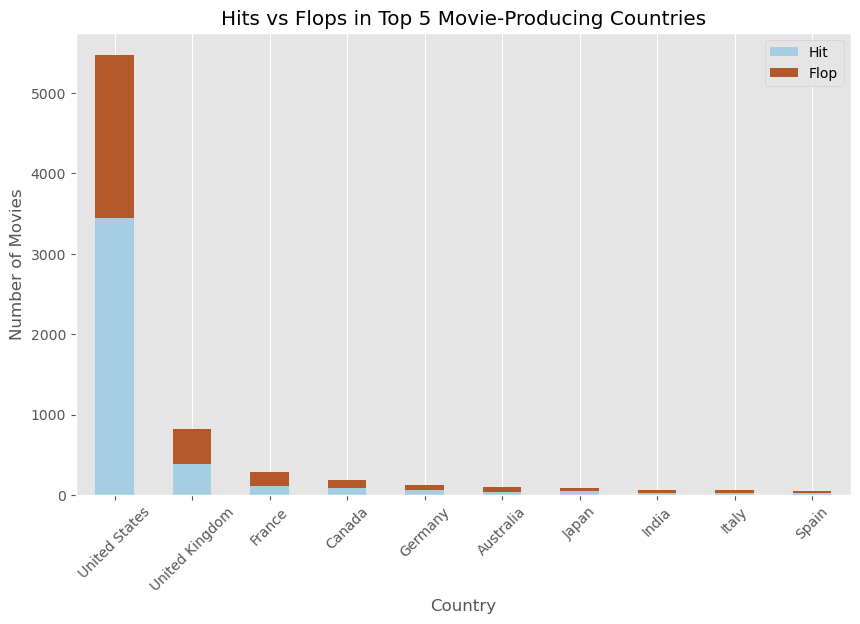

In [71]:
country_flop_counts[['Hit', 'Flop']].plot(kind='bar', stacked=True, figsize=(10,6), colormap='Paired')
plt.title("Hits vs Flops in Top 5 Movie-Producing Countries")
plt.xlabel("Country")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

C:\Users\Aishw\AppData\Local\Temp\ipykernel_20860\2638446190.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_flop_counts.index, y='Success Rate (%)', data=country_flop_counts.reset_index(), palette='Set2')


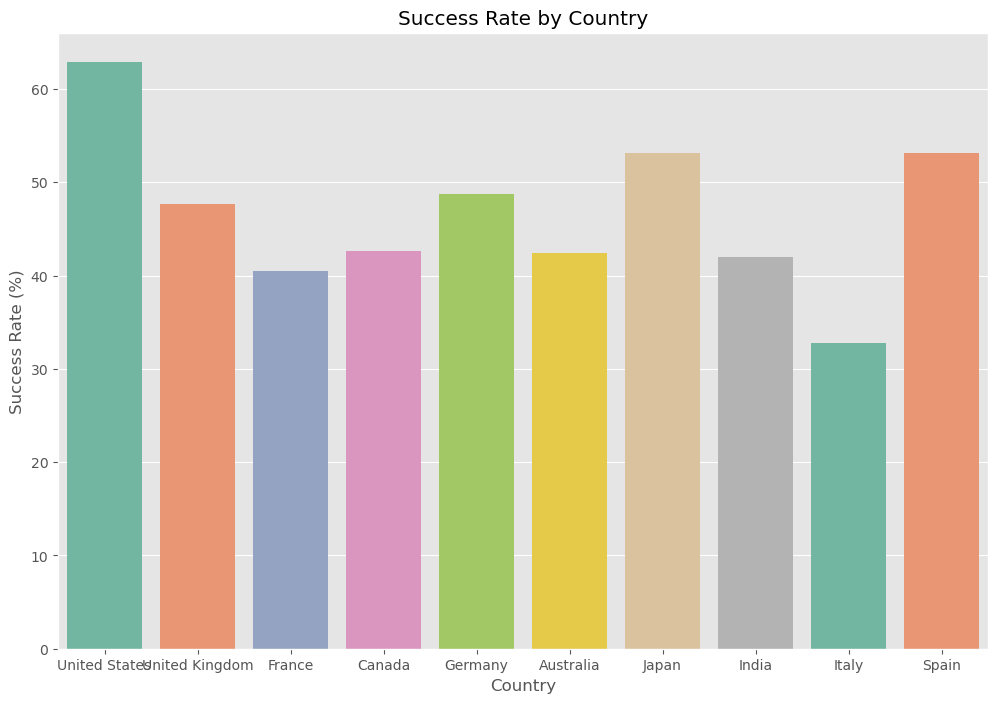

In [72]:
sns.barplot(x=country_flop_counts.index, y='Success Rate (%)', data=country_flop_counts.reset_index(), palette='Set2')
plt.title("Success Rate by Country")
plt.ylabel("Success Rate (%)")
plt.xlabel("Country")
plt.show()

In [74]:
df.to_csv('dataset_analysis.csv', index= False)